In [ ]:
# etf = yf.Ticker("VOO") # ETF that tracks S&P 500
# etf = yf.Ticker("^GSPC") # ETF that tracks S&P 500

In [1]:
import yfinance as yf
stock = yf.Ticker("NVDA") 
current_price = stock.info.get('regularMarketPrice')
print(f"Current stock S&P 500 Price: {current_price}\n")
df = stock.history(period='max', interval="1mo")
print(df)

Current stock S&P 500 Price: 220.78

                                 Open        High         Low       Close  \
Date                                                                        
1999-01-01 00:00:00-05:00    0.040109    0.044765    0.035573    0.036289   
1999-02-01 00:00:00-05:00    0.036289    0.050137    0.033067    0.041900   
1999-03-01 00:00:00-05:00    0.042974    0.043930    0.034857    0.040348   
1999-04-01 00:00:00-05:00    0.040348    0.042019    0.030559    0.034857   
1999-05-01 00:00:00-04:00    0.035215    0.040825    0.031514    0.032589   
...                               ...         ...         ...         ...   
2026-01-01 00:00:00-05:00  189.829721  194.479478  177.600387  191.119659   
2026-02-01 00:00:00-05:00  187.189873  197.619317  171.020749  177.180420   
2026-03-01 00:00:00-05:00  175.000516  188.869775  164.261108  174.390549   
2026-04-01 00:00:00-04:00  176.000000  216.830002  171.369995  199.570007   
2026-05-01 00:00:00-04:00  201.279999  

In [9]:
import pandas as pd
constituents_df = pd.read_csv('constituents.csv')
print(constituents_df)

    Symbol             Security             GICS Sector  \
0      MMM                   3M             Industrials   
1      AOS          A. O. Smith             Industrials   
2      ABT  Abbott Laboratories             Health Care   
3     ABBV               AbbVie             Health Care   
4      ACN            Accenture  Information Technology   
..     ...                  ...                     ...   
498    XYL           Xylem Inc.             Industrials   
499    YUM          Yum! Brands  Consumer Discretionary   
500   ZBRA   Zebra Technologies  Information Technology   
501    ZBH        Zimmer Biomet             Health Care   
502    ZTS               Zoetis             Health Care   

                                GICS Sub-Industry    Headquarters Location  \
0                        Industrial Conglomerates    Saint Paul, Minnesota   
1                               Building Products     Milwaukee, Wisconsin   
2                           Health Care Equipment  North 

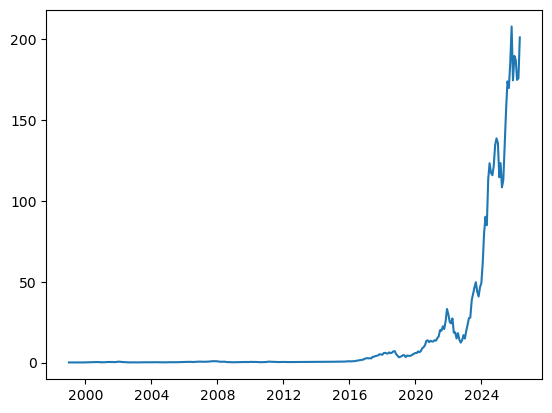

In [10]:
import matplotlib.pyplot as plt

plt.plot(df['Open'])
# plt.plot(live_data['High'])
# plt.plot(live_data['Low'])
plt.show()

In [16]:
df['SMA_50'] = df['Close'].rolling(window=50).mean()  # 50-day moving average
ath_price = df['High'].max()
ath_date = df['High'].idxmax()

# Influence of Tech Stocks
## S&P 500 Top-10 Holdings Monthly Weight Pipeline
### Build a CSV of the top 10 S&P 500 companies (by index weight) for every month from January 1993 through April 2026.

In [1]:
import pandas as pd
import os

archive_path = 'archive'
dfs = {}

for f in sorted(os.listdir(archive_path)):
    df = pd.read_csv(os.path.join(archive_path, f))
    dfs[f] = df

In [2]:
print(list(dfs.keys()))

['2000.csv', '2001.csv', '2002.csv', '2003.csv', '2004.csv', '2005.csv', '2006.csv', '2007.csv', '2008.csv', '2009.csv', '2010.csv', '2011.csv', '2012.csv', '2013.csv', '2014.csv', '2015.csv', '2016.csv', '2017.csv', '2018.csv', '2019.csv', '2020.csv', '2021.csv', '2022.csv', '2023.csv', '2024.csv', '2025.csv']


In [3]:
print(dfs['2009.csv'])

                         Company  Weight Ticker
0               Exxon Mobil Corp   3.532    XOM
1                 Microsoft Corp   2.150   MSFT
2            General Electric Co   1.869     GE
3            JPMorgan Chase & Co   1.846    JPM
4            Procter & Gamble Co   1.811     PG
..                           ...     ...    ...
495               Convergys Corp   0.013   CNXC
496                    MBIA, Inc   0.013    MBI
497                Meredith Corp   0.012    IAC
498  New York Times Co (Class A)   0.010    NYT
499         Titanium Metals Corp   0.009    PCP

[500 rows x 3 columns]


In [4]:
rows = []
for filename, df in dfs.items():
    year = int(filename.replace('.csv', ''))
    top10 = df.nlargest(10, 'Weight')[['Company', 'Ticker', 'Weight']].reset_index(drop=True)
    row = {'Year': year}
    for i, r in top10.iterrows():
        row[f'Company_{i+1}'] = r['Company']
        row[f'Ticker_{i+1}'] = r['Ticker']
        row[f'Weight_{i+1}'] = r['Weight']
    rows.append(row)

top10_df = pd.DataFrame(rows).sort_values('Year').reset_index(drop=True)
top10_df.to_csv('top10.csv')
print(top10_df)

    Year            Company_1 Ticker_1  Weight_1            Company_2  \
0   2000  General Electric Co       GE     4.525   Cisco Systems, Inc   
1   2001  General Electric Co       GE     3.917       Microsoft Corp   
2   2002  General Electric Co       GE     3.265       Microsoft Corp   
3   2003       Microsoft Corp     MSFT     3.267  General Electric Co   
4   2004  General Electric Co       GE     3.410     Exxon Mobil Corp   
5   2005     Exxon Mobil Corp      XOM     3.614  General Electric Co   
6   2006     Exxon Mobil Corp      XOM     3.316  General Electric Co   
7   2007     Exxon Mobil Corp      XOM     3.812  General Electric Co   
8   2008     Exxon Mobil Corp      XOM     3.962  General Electric Co   
9   2009     Exxon Mobil Corp      XOM     3.532       Microsoft Corp   
10  2010    Exxon Mobil Corp.      XOM     3.044          Apple, Inc.   
11  2011          Apple, Inc.     AAPL     3.431    Exxon Mobil Corp.   
12  2012          Apple, Inc.     AAPL     4.856   

# Yearly Plots

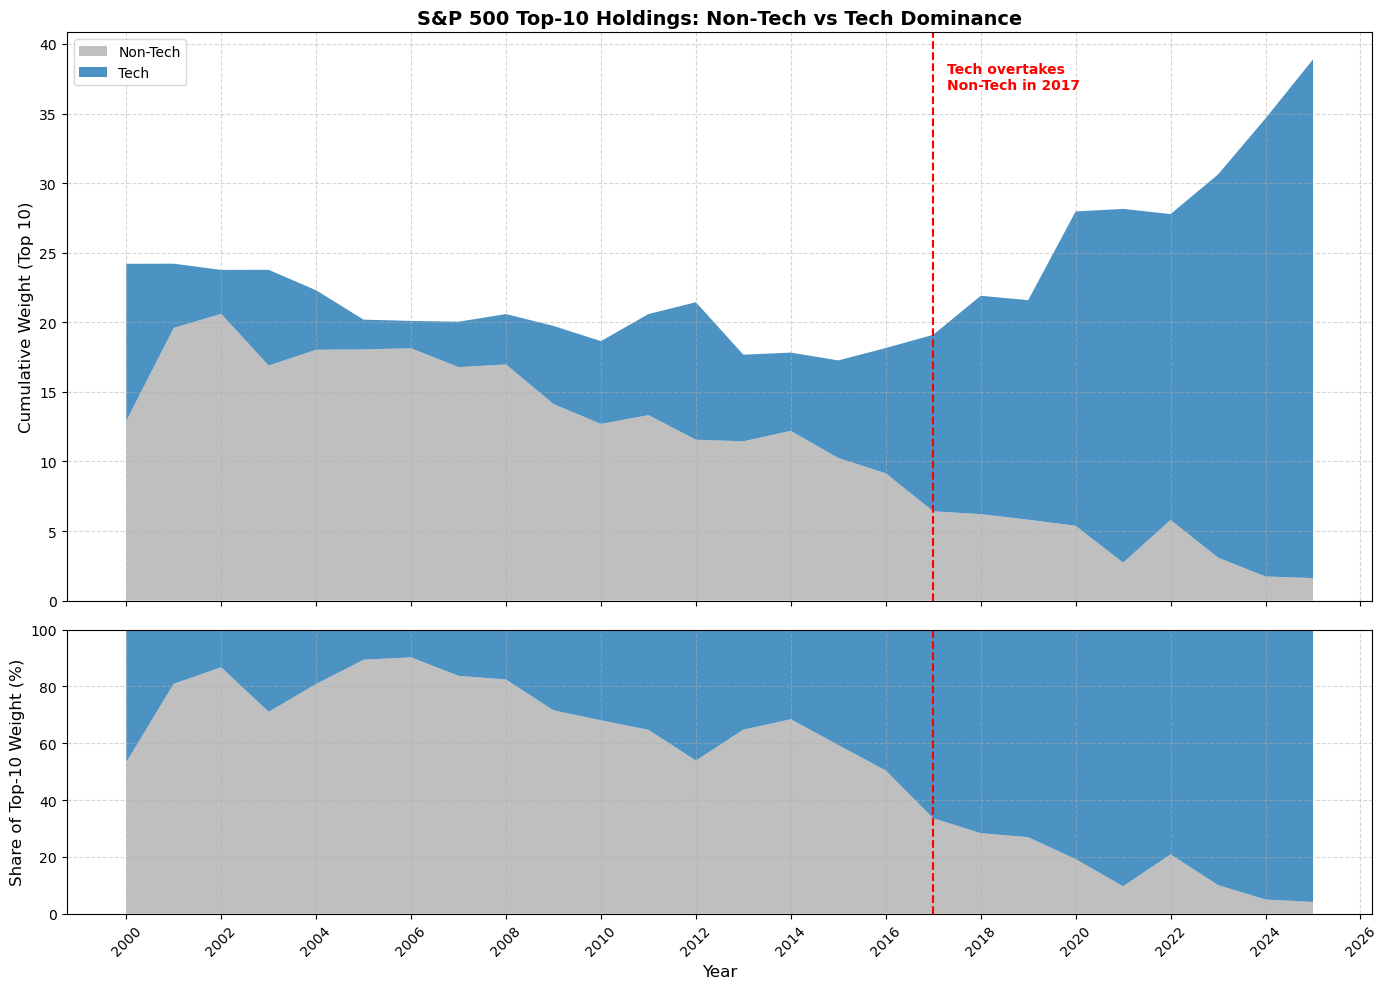

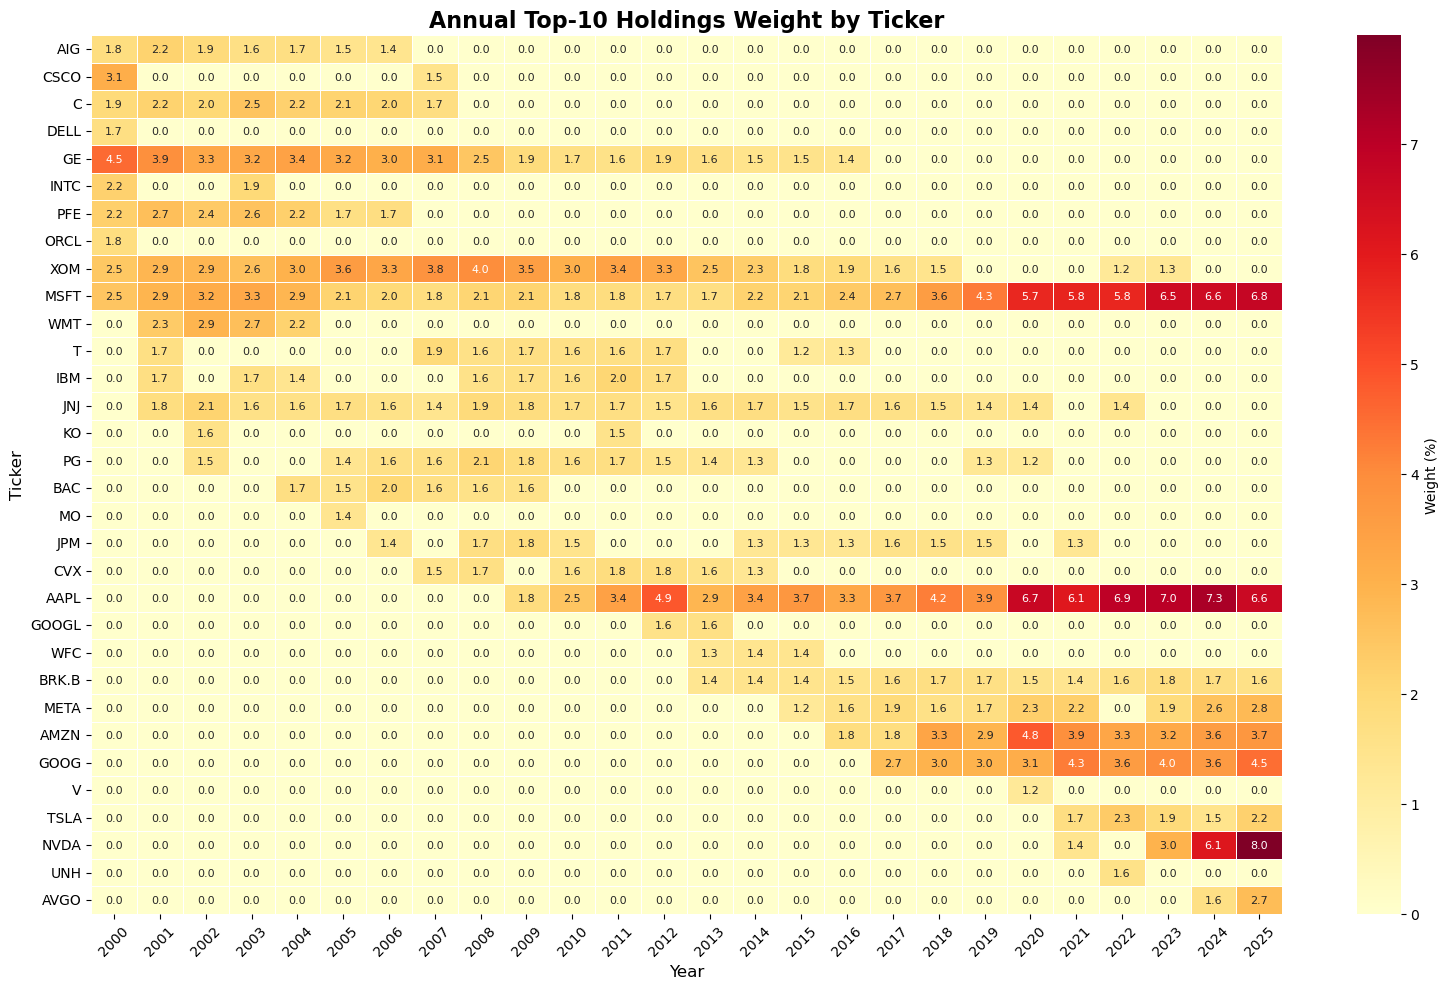

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

top10_df = pd.read_csv('top10.csv')

records = []
for _, row in top10_df.iterrows():
    year = row['Year']
    for rank in range(1, 11):
        ticker = row[f'Ticker_{rank}']
        weight = row[f'Weight_{rank}']
        records.append({'Year': year, 'Rank': rank, 'Ticker': ticker, 'Weight': weight})

long_df = pd.DataFrame(records)

tech_tickers = {
    'MSFT', 'AAPL', 'CSCO', 'INTC', 'ORCL', 'IBM', # early tech
    'AMZN', 'META', 'GOOG', 'GOOGL', # internet / platform
    'NVDA', 'AVGO', 'TSLA', # semiconductors / EV
    'DELL', 'HPQ'  # hardware (if present)
}

long_df['Sector'] = long_df['Ticker'].apply(lambda x: 'Tech' if x in tech_tickers else 'Non-Tech')

yearly_sector = (long_df.groupby(['Year', 'Sector'])['Weight'].sum().unstack(fill_value=0).reset_index())
if 'Tech' not in yearly_sector.columns:
    yearly_sector['Tech'] = 0
if 'Non-Tech' not in yearly_sector.columns:
    yearly_sector['Non-Tech'] = 0

yearly_sector['Total'] = yearly_sector['Tech'] + yearly_sector['Non-Tech']
yearly_sector['Tech_pct'] = 100 * yearly_sector['Tech'] / yearly_sector['Total']
yearly_sector['NonTech_pct'] = 100 * yearly_sector['Non-Tech'] / yearly_sector['Total']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# absolute weights (stacked area)
ax1.stackplot(yearly_sector['Year'], yearly_sector['Non-Tech'], yearly_sector['Tech'], labels=['Non-Tech', 'Tech'], colors=['#b0b0b0', '#1f77b4'], alpha=0.8)
ax1.set_ylabel('Cumulative Weight (Top 10)', fontsize=12)
ax1.set_title('S&P 500 Top‑10 Holdings: Non‑Tech vs Tech Dominance', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.5)

# percentage split (stacked area 0-100%)
ax2.stackplot(yearly_sector['Year'], yearly_sector['NonTech_pct'], yearly_sector['Tech_pct'], labels=['Non-Tech %', 'Tech %'], colors=['#b0b0b0', '#1f77b4'], alpha=0.8)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Share of Top‑10 Weight (%)', fontsize=12)
ax2.set_ylim(0, 100)
ax2.grid(True, linestyle='--', alpha=0.5)

# Mark the year when Tech first exceeds Non-Tech (if any)
cross_year = yearly_sector[yearly_sector['Tech'] > yearly_sector['Non-Tech']]['Year'].min()
if pd.notna(cross_year):
    ax1.axvline(x=cross_year, color='red', linestyle='--', linewidth=1.5)
    ax2.axvline(x=cross_year, color='red', linestyle='--', linewidth=1.5)
    ax1.text(cross_year + 0.3, ax1.get_ylim()[1]*0.9, f'Tech overtakes\nNon-Tech in {int(cross_year)}', color='red', fontsize=10, fontweight='bold')

for ax in [ax1, ax2]:
    ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
# plt.savefig('tech_vs_nonteach_shift.png', dpi=150, bbox_inches='tight')
plt.show()

pivot = long_df.pivot_table(index='Ticker', columns='Year', values='Weight', aggfunc='sum', fill_value=0)

first_year = long_df.groupby('Ticker')['Year'].min().sort_values()
pivot = pivot.loc[first_year.index]

plt.figure(figsize=(16, 10))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=.5, cbar_kws={'label': 'Weight (%)'},
            annot_kws={'size': 8})
plt.title('Annual Top‑10 Holdings Weight by Ticker', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Ticker', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig('top10_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Getting & Aggregating Monthly Data

In [7]:
selected_cols = ['Ticker_1', 'Ticker_2', 'Ticker_3', 'Ticker_4', 'Ticker_5', 'Ticker_6', 'Ticker_7', 'Ticker_8', 'Ticker_9', 'Ticker_10']

unique_array = pd.unique(top10_df[selected_cols].values.ravel())
unique_list = unique_array.tolist()
print(unique_list)

['GE', 'CSCO', 'MSFT', 'XOM', 'PFE', 'INTC', 'C', 'ORCL', 'AIG', 'DELL', 'WMT', 'JNJ', 'IBM', 'T', 'KO', 'PG', 'BAC', 'MO', 'JPM', 'CVX', 'AAPL', 'GOOGL', 'BRK.B', 'WFC', 'META', 'AMZN', 'GOOG', 'V', 'TSLA', 'NVDA', 'UNH', 'AVGO']


In [7]:
import yfinance as yf
import pandas as pd
import os

top10_df = pd.read_csv('top10.csv')

long_records = []
for _, row in top10_df.iterrows():
    year = int(row['Year'])
    for rank in range(1, 11):
        long_records.append({
            'Year': year,
            'Rank': rank,
            'Ticker': row[f'Ticker_{rank}'],
            'Company': row[f'Company_{rank}'],
            'Weight': row[f'Weight_{rank}'],
        })

weight_df = pd.DataFrame(long_records)   # 260 rows × 5 cols
print(f"weight_df shape: {weight_df.shape}")
print(weight_df.head(12).to_string())

weight_df shape: (260, 5)
    Year  Rank Ticker                            Company  Weight
0   2000     1     GE                General Electric Co   4.525
1   2000     2   CSCO                 Cisco Systems, Inc   3.105
2   2000     3   MSFT                     Microsoft Corp   2.514
3   2000     4    XOM                   Exxon Mobil Corp   2.459
4   2000     5    PFE                        Pfizer, Inc   2.245
5   2000     6   INTC                         Intel Corp   2.210
6   2000     7      C                     Citigroup, Inc   1.926
7   2000     8   ORCL                        Oracle Corp   1.756
8   2000     9    AIG  American International Group, Inc   1.756
9   2000    10   DELL                           EMC Corp   1.708
10  2001     1     GE                General Electric Co   3.917
11  2001     2   MSFT                     Microsoft Corp   2.918


In [10]:
from tqdm.notebook import tqdm

tickers = [
    'GE','CSCO','MSFT','XOM','PFE','INTC','C','ORCL','AIG','DELL',
    'WMT','JNJ','IBM','T','KO','PG','BAC','MO','JPM','CVX',
    'AAPL','GOOGL','BRK-B','WFC','META','AMZN','GOOG','V','TSLA','NVDA',
    'UNH','AVGO'
]
TICKER_MAP_REVERSE = {'BRK-B': 'BRK.B'} 

price_frames = []
for ticker in tqdm(tickers):
    try:
        stock = yf.Ticker(ticker)
        df = stock.history(period='max', interval='1mo')
        if df.empty:
            print(f"  {ticker}: NO DATA"); continue

        df = df.reset_index()
        df['Date'] = pd.to_datetime(df['Date']).dt.tz_localize(None)
        df['Date'] = df['Date'].dt.to_period('M').dt.to_timestamp()

        keep = ['Date','Open','High','Low','Close','Volume','Dividends']
        df = df[[c for c in keep if c in df.columns]].copy()
        df['Ticker'] = TICKER_MAP_REVERSE.get(ticker, ticker)
        price_frames.append(df)
        print(f"  {ticker}: {len(df)} rows")
    except Exception as e:
        print(f"  {ticker}: ERROR {e}")

  0%|          | 0/32 [00:00<?, ?it/s]

  GE: 773 rows
  CSCO: 436 rows
  MSFT: 483 rows
  XOM: 497 rows
  PFE: 497 rows
  INTC: 497 rows
  C: 497 rows
  ORCL: 483 rows
  AIG: 497 rows
  DELL: 118 rows
  WMT: 646 rows
  JNJ: 497 rows
  IBM: 773 rows
  T: 511 rows
  KO: 497 rows
  PG: 497 rows
  BAC: 497 rows
  MO: 497 rows
  JPM: 497 rows
  CVX: 497 rows
  AAPL: 497 rows
  GOOGL: 262 rows
  BRK-B: 361 rows
  WFC: 497 rows
  META: 169 rows
  AMZN: 349 rows
  GOOG: 262 rows
  V: 219 rows
  TSLA: 192 rows
  NVDA: 329 rows
  UNH: 497 rows
  AVGO: 202 rows


In [11]:
all_prices = pd.concat(price_frames, ignore_index=True)
all_prices['Year'] = all_prices['Date'].dt.year
all_prices = all_prices[(all_prices['Year'] >= 2000) & (all_prices['Year'] <= 2025)]
print(f"\nall_prices shape: {all_prices.shape}")   # ~9,189 rows

monthly_df = all_prices.merge(weight_df, on=['Ticker', 'Year'], how='inner')

col_order = ['Date','Year','Rank','Ticker','Company',
             'Open','High','Low','Close','Volume','Dividends','Weight']
monthly_df = monthly_df[col_order]
monthly_df = monthly_df.sort_values(['Year','Rank','Date']).reset_index(drop=True)

print(f"\nFinal monthly_df shape: {monthly_df.shape}")

print(f"\nUnique tickers still present: {sorted(monthly_df['Ticker'].unique())}")
print(f"Any NaN in Weight? {monthly_df['Weight'].isna().any()}")    # must be False
print(f"Any NaN in Company? {monthly_df['Company'].isna().any()}")  # must be False

print("\nTop-10 for year 2000 (all 12 months × 10 stocks = 120 rows):")
y2000 = monthly_df[monthly_df['Year'] == 2000]
print(f"  Rows: {len(y2000)}")
print(y2000[['Date','Rank','Ticker','Company','Close','Weight']].to_string())

print("\nTop-10 for year 2025 (all 12 months × 10 stocks = 120 rows):")
y2025 = monthly_df[monthly_df['Year'] == 2025]
print(f"  Rows: {len(y2025)}")
print(y2025[['Date','Rank','Ticker','Company','Close','Weight']].head(30).to_string())

print("\nSample — NVDA's top-10 appearances:")
print(monthly_df[monthly_df['Ticker'] == 'NVDA'][['Date','Year','Rank','Company','Close','Weight']].to_string())

monthly_df.to_csv('top10_monthly.csv', index=False)
print(f"\nSaved → top10_monthly.csv  ({monthly_df.shape[0]} rows × {monthly_df.shape[1]} cols)")


all_prices shape: (9189, 9)

Final monthly_df shape: (3108, 12)

Unique tickers still present: ['AAPL', 'AIG', 'AMZN', 'AVGO', 'BAC', 'BRK.B', 'C', 'CSCO', 'CVX', 'GE', 'GOOG', 'GOOGL', 'IBM', 'INTC', 'JNJ', 'JPM', 'KO', 'META', 'MO', 'MSFT', 'NVDA', 'ORCL', 'PFE', 'PG', 'T', 'TSLA', 'UNH', 'V', 'WFC', 'WMT', 'XOM']
Any NaN in Weight? False
Any NaN in Company? False

Top-10 for year 2000 (all 12 months × 10 stocks = 120 rows):
  Rows: 108
          Date  Rank Ticker                            Company        Close  Weight
0   2000-01-01     1     GE                General Electric Co   115.631218   4.525
1   2000-02-01     1     GE                General Electric Co   114.228958   4.525
2   2000-03-01     1     GE                General Electric Co   134.291794   4.525
3   2000-04-01     1     GE                General Electric Co   136.094437   4.525
4   2000-05-01     1     GE                General Electric Co   136.635330   4.525
5   2000-06-01     1     GE                General E

In [13]:
"""
EDA for monthly_df — S&P 500 Top-10 Monthly Price Data (2000–2025)
=================================================================
Runs immediately after monthly_df is defined; no extra imports needed
beyond what the data-build script already uses.
"""

import pandas as pd
import numpy as np

# ── helpers ────────────────────────────────────────────────────────────────
SEP  = "=" * 72
sep  = "-" * 72

def header(title):
    print(f"\n{SEP}")
    print(f"  {title}")
    print(SEP)

def subheader(title):
    print(f"\n{sep}")
    print(f"  {title}")
    print(sep)


# ══════════════════════════════════════════════════════════════════════════
# 0. BASIC SHAPE & DTYPES
# ══════════════════════════════════════════════════════════════════════════
header("0 · SHAPE & DTYPES")
print(f"Rows : {monthly_df.shape[0]:,}")
print(f"Cols : {monthly_df.shape[1]}")
print()
print(monthly_df.dtypes)
print()
print("Missing values per column:")
print(monthly_df.isna().sum())
print()
print("Duplicate rows:", monthly_df.duplicated().sum())


# ══════════════════════════════════════════════════════════════════════════
# 1. DATE / TEMPORAL COVERAGE
# ══════════════════════════════════════════════════════════════════════════
header("1 · TEMPORAL COVERAGE")
print(f"Date range : {monthly_df['Date'].min().date()}  →  {monthly_df['Date'].max().date()}")
print(f"Years      : {sorted(monthly_df['Year'].unique())}")
print(f"Unique years   : {monthly_df['Year'].nunique()}")
print(f"Unique months  : {monthly_df['Date'].dt.month.nunique()}")

rows_per_year = monthly_df.groupby('Year').size()
print("\nRows per year (expect 120 = 12 months × 10 ranks):")
print(rows_per_year.to_string())
incomplete = rows_per_year[rows_per_year != 120]
if incomplete.empty:
    print("\n✓ Every year has exactly 120 rows.")
else:
    print(f"\n⚠ Years with ≠ 120 rows:\n{incomplete}")


# ══════════════════════════════════════════════════════════════════════════
# 2. TICKER / COMPANY UNIVERSE
# ══════════════════════════════════════════════════════════════════════════
header("2 · TICKER / COMPANY UNIVERSE")
print(f"Unique tickers  : {monthly_df['Ticker'].nunique()}")
print(f"Unique companies: {monthly_df['Company'].nunique()}")
print()

ticker_years = (
    monthly_df.groupby('Ticker')['Year']
    .agg(['min', 'max', 'nunique'])
    .rename(columns={'min': 'first_year', 'max': 'last_year', 'nunique': 'n_years'})
    .sort_values('n_years', ascending=False)
)
print("Years each ticker appears in the top-10:")
print(ticker_years.to_string())

# How many distinct tickers appear per year?
tickers_per_year = monthly_df.groupby('Year')['Ticker'].nunique()
print("\nDistinct tickers per year:")
print(tickers_per_year.to_string())


# ══════════════════════════════════════════════════════════════════════════
# 3. RANK DISTRIBUTION
# ══════════════════════════════════════════════════════════════════════════
header("3 · RANK DISTRIBUTION")
rank_counts = monthly_df.groupby(['Ticker', 'Rank']).size().unstack(fill_value=0)
print("Months each ticker held each rank (top = most months at rank-1):")
# Show only tickers that ever held rank 1 or 2
rank1_tickers = monthly_df[monthly_df['Rank'] == 1]['Ticker'].unique()
print(rank_counts.loc[rank_counts.index.isin(rank1_tickers)].sort_values(1, ascending=False).to_string())

print("\nRank-1 holder per year:")
rank1_per_year = (
    monthly_df[monthly_df['Rank'] == 1]
    .drop_duplicates('Year')[['Year', 'Ticker', 'Company', 'Weight']]
    .sort_values('Year')
)
print(rank1_per_year.to_string(index=False))


# ══════════════════════════════════════════════════════════════════════════
# 4. WEIGHT ANALYSIS
# ══════════════════════════════════════════════════════════════════════════
header("4 · WEIGHT ANALYSIS (index weight % per year)")

# One weight per ticker-year
weight_snapshot = monthly_df.drop_duplicates(['Ticker', 'Year'])[['Year', 'Ticker', 'Company', 'Rank', 'Weight']]

print("\nHeaviest single-stock weight ever seen:")
heaviest = weight_snapshot.nlargest(10, 'Weight')[['Year', 'Ticker', 'Company', 'Rank', 'Weight']]
print(heaviest.to_string(index=False))

print("\nTop-10 combined weight per year (sum of all 10 weights):")
total_weight = weight_snapshot.groupby('Year')['Weight'].sum().reset_index()
total_weight.columns = ['Year', 'Total_Weight_%']
print(total_weight.to_string(index=False))

print("\nWeight stats per rank (across all years):")
print(
    weight_snapshot.groupby('Rank')['Weight']
    .agg(['mean', 'min', 'max', 'std'])
    .round(3)
    .to_string()
)


# ══════════════════════════════════════════════════════════════════════════
# 5. PRICE STATISTICS — PER TICKER (adjusted close)
# ══════════════════════════════════════════════════════════════════════════
header("5 · CLOSE PRICE STATS PER TICKER")
price_stats = (
    monthly_df.groupby('Ticker')['Close']
    .agg(
        n_obs    = 'count',
        mean_px  = 'mean',
        min_px   = 'min',
        max_px   = 'max',
        std_px   = 'std',
        last_px  = 'last',
    )
    .round(2)
    .sort_values('mean_px', ascending=False)
)
print(price_stats.to_string())


# ══════════════════════════════════════════════════════════════════════════
# 6. MONTHLY RETURNS — PER TICKER
# ══════════════════════════════════════════════════════════════════════════
header("6 · MONTHLY RETURN STATS PER TICKER")

monthly_df_sorted = monthly_df.sort_values(['Ticker', 'Date'])
monthly_df_sorted['Monthly_Ret'] = (
    monthly_df_sorted.groupby('Ticker')['Close'].pct_change()
)

ret_stats = (
    monthly_df_sorted.groupby('Ticker')['Monthly_Ret']
    .agg(
        mean_ret  = 'mean',
        median_ret= 'median',
        std_ret   = 'std',
        min_ret   = 'min',
        max_ret   = 'max',
        pos_months= lambda s: (s > 0).sum(),
        neg_months= lambda s: (s < 0).sum(),
    )
    .round(4)
    .sort_values('mean_ret', ascending=False)
)
print(ret_stats.to_string())

print("\nTop-5 single-month gains:")
top_gains = monthly_df_sorted.nlargest(5, 'Monthly_Ret')[
    ['Date', 'Ticker', 'Company', 'Close', 'Monthly_Ret']
]
print(top_gains.to_string(index=False))

print("\nTop-5 single-month losses:")
top_losses = monthly_df_sorted.nsmallest(5, 'Monthly_Ret')[
    ['Date', 'Ticker', 'Company', 'Close', 'Monthly_Ret']
]
print(top_losses.to_string(index=False))


# ══════════════════════════════════════════════════════════════════════════
# 7. TOTAL RETURN (first → last appearance in dataset)
# ══════════════════════════════════════════════════════════════════════════
header("7 · TOTAL RETURN — first vs last price in dataset")

first_last = (
    monthly_df.sort_values('Date')
    .groupby('Ticker')['Close']
    .agg(first_px='first', last_px='last')
)
first_last['total_return_%'] = ((first_last['last_px'] / first_last['first_px']) - 1) * 100
first_last = first_last.round(2).sort_values('total_return_%', ascending=False)
print(first_last.to_string())


# ══════════════════════════════════════════════════════════════════════════
# 8. VOLUME ANALYSIS
# ══════════════════════════════════════════════════════════════════════════
header("8 · VOLUME ANALYSIS PER TICKER")

vol_stats = (
    monthly_df.groupby('Ticker')['Volume']
    .agg(
        mean_vol   = 'mean',
        median_vol = 'median',
        max_vol    = 'max',
    )
    .applymap(lambda x: f"{x:,.0f}")
    .sort_values('mean_vol', ascending=False)
)
print(vol_stats.to_string())

print("\nYear with highest total volume (all tickers summed):")
vol_by_year = monthly_df.groupby('Year')['Volume'].sum().sort_values(ascending=False)
print(vol_by_year.head(5).apply(lambda x: f"{x:,.0f}").to_string())


# ══════════════════════════════════════════════════════════════════════════
# 9. SECTOR / ERA SNAPSHOT — who dominated each decade?
# ══════════════════════════════════════════════════════════════════════════
header("9 · ERA SNAPSHOT — dominant tickers by decade")

bins   = [1999, 2009, 2019, 2025]
labels = ['2000s', '2010s', '2020s']
monthly_df['Era'] = pd.cut(monthly_df['Year'], bins=bins, labels=labels)

era_counts = (
    monthly_df.groupby(['Era', 'Ticker'])
    .size()
    .reset_index(name='months_in_top10')
    .sort_values(['Era', 'months_in_top10'], ascending=[True, False])
)

for era in labels:
    sub = era_counts[era_counts['Era'] == era].head(5)
    print(f"\n  {era} — top-5 by months in top-10:")
    print(sub[['Ticker', 'months_in_top10']].to_string(index=False))


# # ══════════════════════════════════════════════════════════════════════════
# # 10. CORRELATION — monthly returns across tickers (pivot)
# # ══════════════════════════════════════════════════════════════════════════
# header("10 · RETURN CORRELATION MATRIX (tickers with ≥ 36 obs)")

# ret_pivot = (
#     monthly_df_sorted[monthly_df_sorted['Monthly_Ret'].notna()]
#     .pivot_table(index='Date', columns='Ticker', values='Monthly_Ret')
# )
# # Keep only tickers with enough data
# sufficient = ret_pivot.columns[ret_pivot.notna().sum() >= 36]
# corr = ret_pivot[sufficient].corr().round(3)
# print(corr.to_string())

# print("\nMost correlated pairs (excl. self):")
# corr_pairs = (
#     corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
#     .stack()
#     .reset_index()
# )
# corr_pairs.columns = ['Ticker_A', 'Ticker_B', 'Corr']
# print(corr_pairs.nlargest(10, 'Corr').to_string(index=False))

# print("\nLeast correlated pairs:")
# print(corr_pairs.nsmallest(5, 'Corr').to_string(index=False))


# ══════════════════════════════════════════════════════════════════════════
# 11. DIVIDEND ANALYSIS
# ══════════════════════════════════════════════════════════════════════════
header("11 · DIVIDEND ANALYSIS")

div_stats = (
    monthly_df.groupby('Ticker')['Dividends']
    .agg(
        total_divs   = 'sum',
        mean_div     = 'mean',
        months_w_div = lambda s: (s > 0).sum(),
    )
    .round(4)
    .sort_values('total_divs', ascending=False)
)
print(div_stats.to_string())

print("\nHighest individual monthly dividend payments:")
print(
    monthly_df.nlargest(10, 'Dividends')[['Date', 'Ticker', 'Company', 'Close', 'Dividends']]
    .to_string(index=False)
)


# ══════════════════════════════════════════════════════════════════════════
# 12. QUICK SUMMARY
# ══════════════════════════════════════════════════════════════════════════
header("12 · QUICK SUMMARY")
print(f"  Period covered    : {monthly_df['Year'].min()} – {monthly_df['Year'].max()}")
print(f"  Total rows        : {len(monthly_df):,}")
print(f"  Unique tickers    : {monthly_df['Ticker'].nunique()}")
print(f"  Avg top-10 weight : {monthly_df.drop_duplicates(['Ticker','Year'])['Weight'].sum() / monthly_df['Year'].nunique():.2f}%")
best_ret = first_last['total_return_%'].idxmax()
worst_ret = first_last['total_return_%'].idxmin()
print(f"  Best total return : {best_ret}  ({first_last.loc[best_ret,'total_return_%']:+.1f}%)")
print(f"  Worst total return: {worst_ret}  ({first_last.loc[worst_ret,'total_return_%']:+.1f}%)")
print(f"  Rank-1 holders    : {monthly_df[monthly_df['Rank']==1]['Ticker'].nunique()} different companies")
print()


  0 · SHAPE & DTYPES
Rows : 3,108
Cols : 14

Date         datetime64[ns]
Year                  int64
Rank                  int64
Ticker               object
Company              object
Open                float64
High                float64
Low                 float64
Close               float64
Volume                int64
Dividends           float64
Weight              float64
Sector               object
Era                category
dtype: object

Missing values per column:
Date         0
Year         0
Rank         0
Ticker       0
Company      0
Open         0
High         0
Low          0
Close        0
Volume       0
Dividends    0
Weight       0
Sector       0
Era          0
dtype: int64

Duplicate rows: 0

  1 · TEMPORAL COVERAGE
Date range : 2000-01-01  →  2025-12-01
Years      : [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64

C:\Users\davem\AppData\Local\Temp\ipykernel_41292\1779940610.py:214: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(lambda x: f"{x:,.0f}")
C:\Users\davem\AppData\Local\Temp\ipykernel_41292\1779940610.py:234: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_df.groupby(['Era', 'Ticker'])


# Visualizing Monthly Data (w/ additional features)

C:\Users\davem\AppData\Local\Temp\ipykernel_41292\2184100570.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g['NormClose'], weights=g['Weight']))


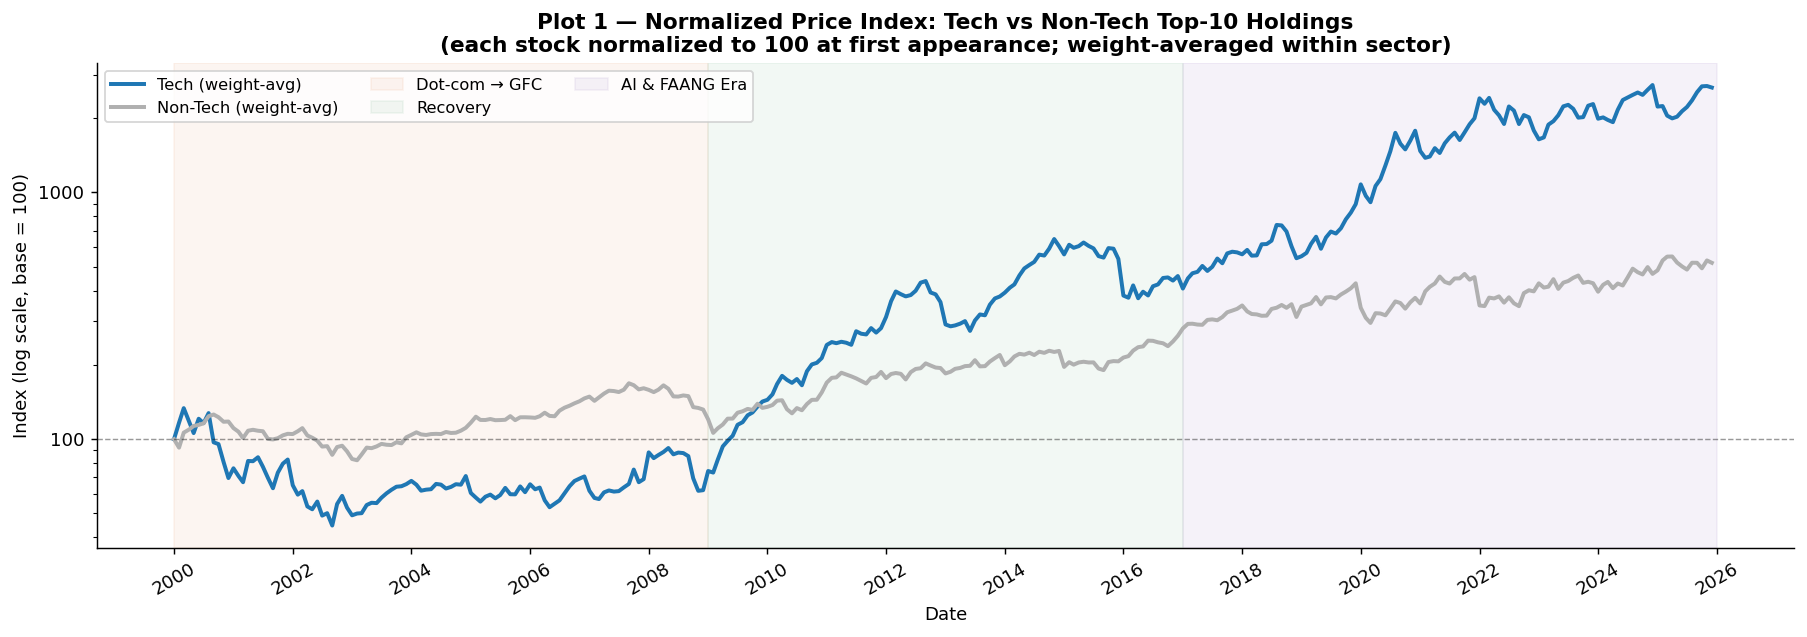

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.lines import Line2D

monthly_df = pd.read_csv('top10_monthly.csv', parse_dates=['Date'])

TECH = {'MSFT','AAPL','CSCO','INTC','ORCL','IBM','AMZN','META', 'GOOG','GOOGL','NVDA','AVGO','TSLA','DELL'}
monthly_df['Sector'] = monthly_df['Ticker'].apply(lambda x: 'Tech' if x in TECH else 'Non-Tech')

def era(year):
    if year <= 2008:  
        return '2000–2008\n(Dot-com → GFC)'
    elif year <= 2016: 
        return '2009–2016\n(Recovery)'
    else:              
        return '2017–2025\n(AI & FAANG)'

monthly_df['Era'] = monthly_df['Year'].apply(era)

TECH_COLOR    = '#1f77b4'
NONTECH_COLOR = '#b0b0b0'
ERA_COLORS    = {'2000–2008\n(Dot-com → GFC)': '#e07b39',
                 '2009–2016\n(Recovery)': '#4a9e6b',
                 '2017–2025\n(AI & FAANG)': '#7b52ab'}

plt.rcParams.update({'figure.dpi': 130, 'font.family': 'sans-serif', 'axes.spines.top': False, 'axes.spines.right': False})

# PLOT 1 — Normalized Price Index: Tech vs Non-Tech  (structural break)

df1 = monthly_df.copy()

# Normalize per ticker
first_close = df1.groupby('Ticker')['Close'].transform('first')
df1['NormClose'] = 100 * df1['Close'] / first_close

# Weight-average within sector × month
df1_grp = (df1.groupby(['Date','Sector'])
             .apply(lambda g: np.average(g['NormClose'], weights=g['Weight']))
             .reset_index(name='WtdNormClose'))

tech_line    = df1_grp[df1_grp['Sector']=='Tech']
nontech_line = df1_grp[df1_grp['Sector']=='Non-Tech']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(tech_line['Date'],    tech_line['WtdNormClose'],
        color=TECH_COLOR,    lw=2.2, label='Tech (weight-avg)')
ax.plot(nontech_line['Date'], nontech_line['WtdNormClose'],
        color=NONTECH_COLOR, lw=2.2, label='Non-Tech (weight-avg)')

# Shade eras
for (y0, y1), label, c in [
    ((2000,2008), 'Dot-com → GFC',  '#e07b39'),
    ((2009,2016), 'Recovery',        '#4a9e6b'),
    ((2017,2025), 'AI & FAANG Era',  '#7b52ab')]:
    ax.axvspan(pd.Timestamp(f'{y0}-01-01'), pd.Timestamp(f'{y1+1}-01-01'),
               alpha=0.07, color=c, label=label)

ax.axhline(100, color='black', lw=0.8, linestyle='--', alpha=0.4)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.set_title('Plot 1 — Normalized Price Index: Tech vs Non-Tech Top-10 Holdings\n'
             '(each stock normalized to 100 at first appearance; weight-averaged within sector)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Index (log scale, base = 100)')
ax.set_xlabel('Date')
ax.legend(fontsize=9, ncol=3)
# ax.xaxis.set_major_locator(mticker.YearLocator(2))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
# plt.savefig('plot1_price_index.png', dpi=150, bbox_inches='tight')
plt.show()



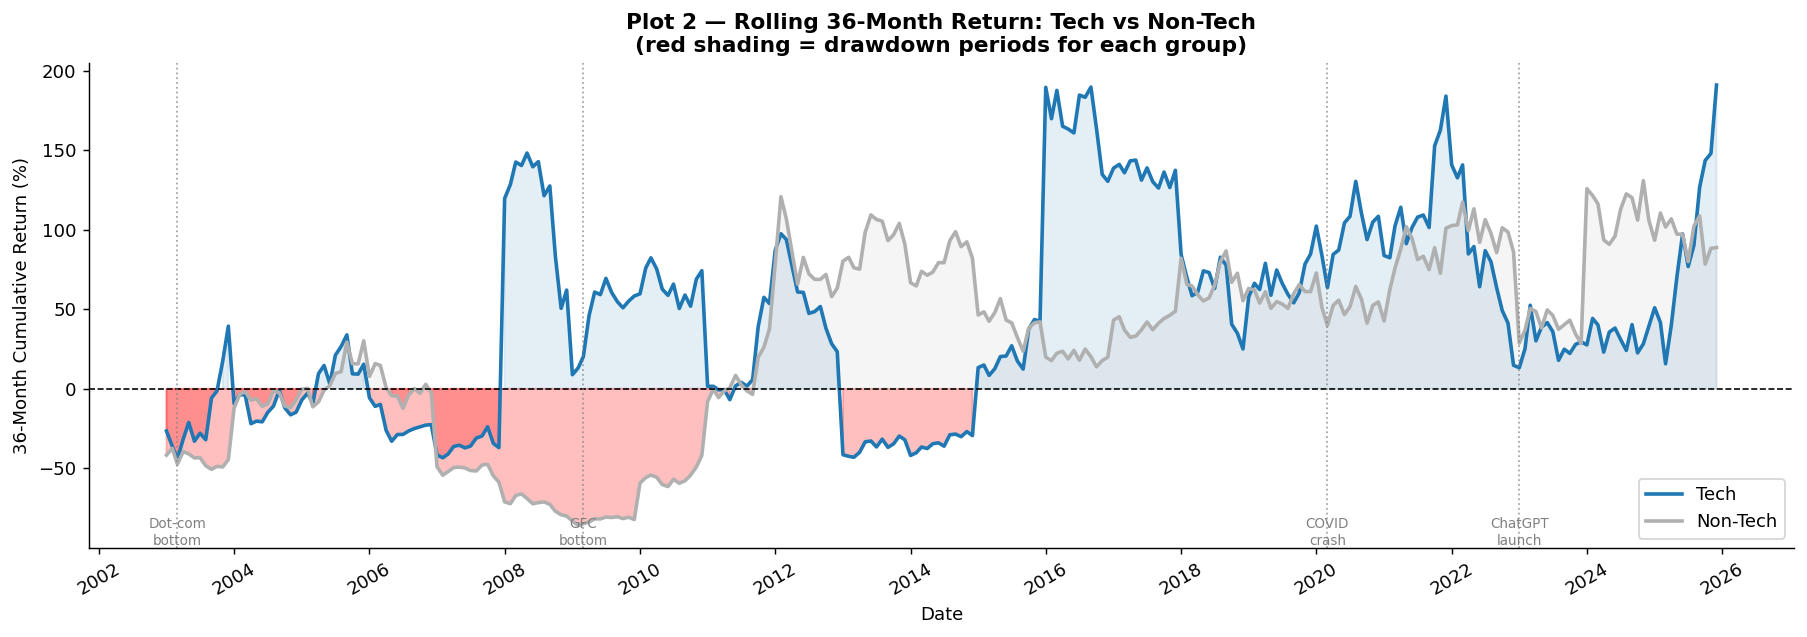

In [2]:
# PLOT 2 — Rolling 36-Month Return: Tech vs Non-Tech
# For each sector group, compute the equal-weighted average Close per month,
# then roll a 36-month window to get cumulative return.

df2 = (monthly_df.groupby(['Date','Sector'])['Close'].mean().reset_index())

results = []
for sector, grp in df2.groupby('Sector'):
    grp = grp.sort_values('Date').set_index('Date')
    grp['Roll36'] = grp['Close'].pct_change(36) * 100   # 36-month % return
    grp['Sector'] = sector
    results.append(grp.reset_index())

df2r = pd.concat(results)

fig, ax = plt.subplots(figsize=(14, 5))
for sector, color in [('Tech', TECH_COLOR), ('Non-Tech', NONTECH_COLOR)]:
    sub = df2r[df2r['Sector'] == sector]
    ax.plot(sub['Date'], sub['Roll36'], color=color, lw=2, label=sector)
    ax.fill_between(sub['Date'], 0, sub['Roll36'], where=sub['Roll36'] > 0, alpha=0.12, color=color)
    ax.fill_between(sub['Date'], 0, sub['Roll36'], where=sub['Roll36'] <= 0, alpha=0.25, color='red')

ax.axhline(0, color='black', lw=0.9, linestyle='--')

events = {
    '2003-03': 'Dot-com\nbottom',
    '2009-03': 'GFC\nbottom',
    '2020-03': 'COVID\ncrash',
    '2023-01': 'ChatGPT\nlaunch'
}
for date_str, label in events.items():
    dt = pd.Timestamp(date_str)
    ax.axvline(dt, color='gray', lw=1, linestyle=':', alpha=0.7)
    ax.text(dt, ax.get_ylim()[0] if ax.get_ylim()[0] > -500 else -300,
            label, fontsize=7.5, ha='center', color='gray',
            va='bottom', rotation=0)

ax.set_title('Plot 2 — Rolling 36-Month Return: Tech vs Non-Tech\n'
             '(red shading = drawdown periods for each group)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('36-Month Cumulative Return (%)')
ax.set_xlabel('Date')
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
# plt.savefig('plot2_rolling_return.png', dpi=150, bbox_inches='tight')
plt.show()

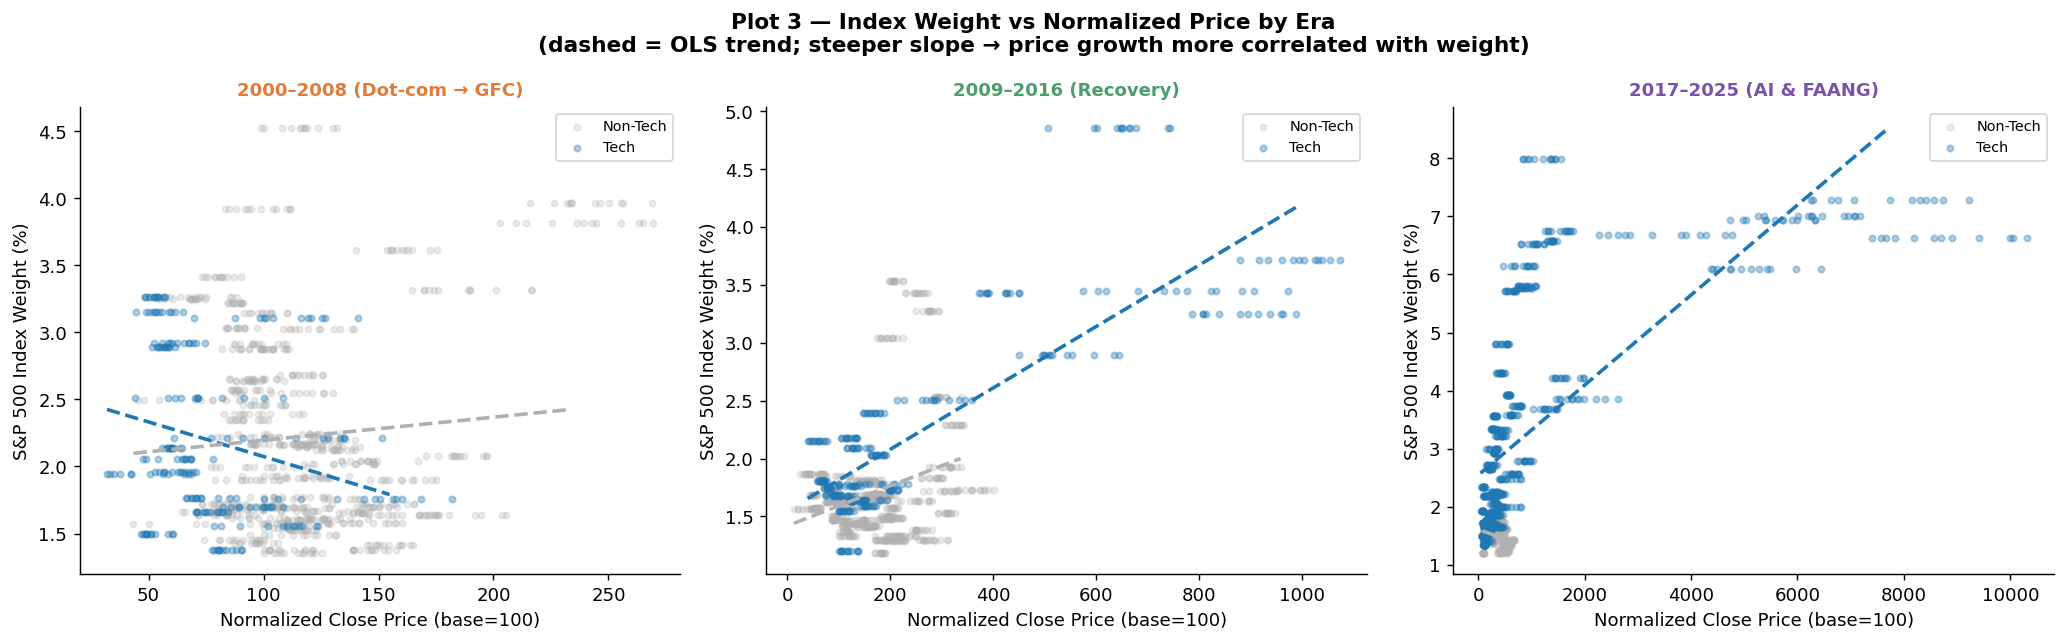

In [3]:
# PLOT 3 — Weight vs Normalized Price by Era  (does price drive weight?)
df3 = df1.copy()  # has NormClose already

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
eras_ordered = ['2000–2008\n(Dot-com → GFC)', '2009–2016\n(Recovery)', '2017–2025\n(AI & FAANG)']

for ax, era_label in zip(axes, eras_ordered):
    sub = df3[df3['Era'] == era_label]
    color = ERA_COLORS[era_label]

    # scatter: one point per stock-month
    tech_sub    = sub[sub['Sector'] == 'Tech']
    nontech_sub = sub[sub['Sector'] == 'Non-Tech']

    ax.scatter(nontech_sub['NormClose'], nontech_sub['Weight'],
               color=NONTECH_COLOR, alpha=0.25, s=12, label='Non-Tech')
    ax.scatter(tech_sub['NormClose'], tech_sub['Weight'],
               color=TECH_COLOR, alpha=0.35, s=12, label='Tech')

    # regression line per sector
    for sector_sub, c in [(tech_sub, TECH_COLOR), (nontech_sub, NONTECH_COLOR)]:
        if len(sector_sub) > 5:
            x = sector_sub['NormClose'].clip(upper=sector_sub['NormClose'].quantile(0.98))
            y = sector_sub['Weight']
            m, b = np.polyfit(x, y, 1)
            xr = np.linspace(x.min(), x.max(), 100)
            ax.plot(xr, m*xr + b, color=c, lw=2, linestyle='--')

    ax.set_title(era_label.replace('\n',' '), fontsize=10, fontweight='bold',
                 color=color)
    ax.set_xlabel('Normalized Close Price (base=100)')
    ax.set_ylabel('S&P 500 Index Weight (%)')
    ax.legend(fontsize=8)

fig.suptitle('Plot 3 — Index Weight vs Normalized Price by Era\n'
             '(dashed = OLS trend; steeper slope → price growth more correlated with weight)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
# plt.savefig('plot3_weight_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

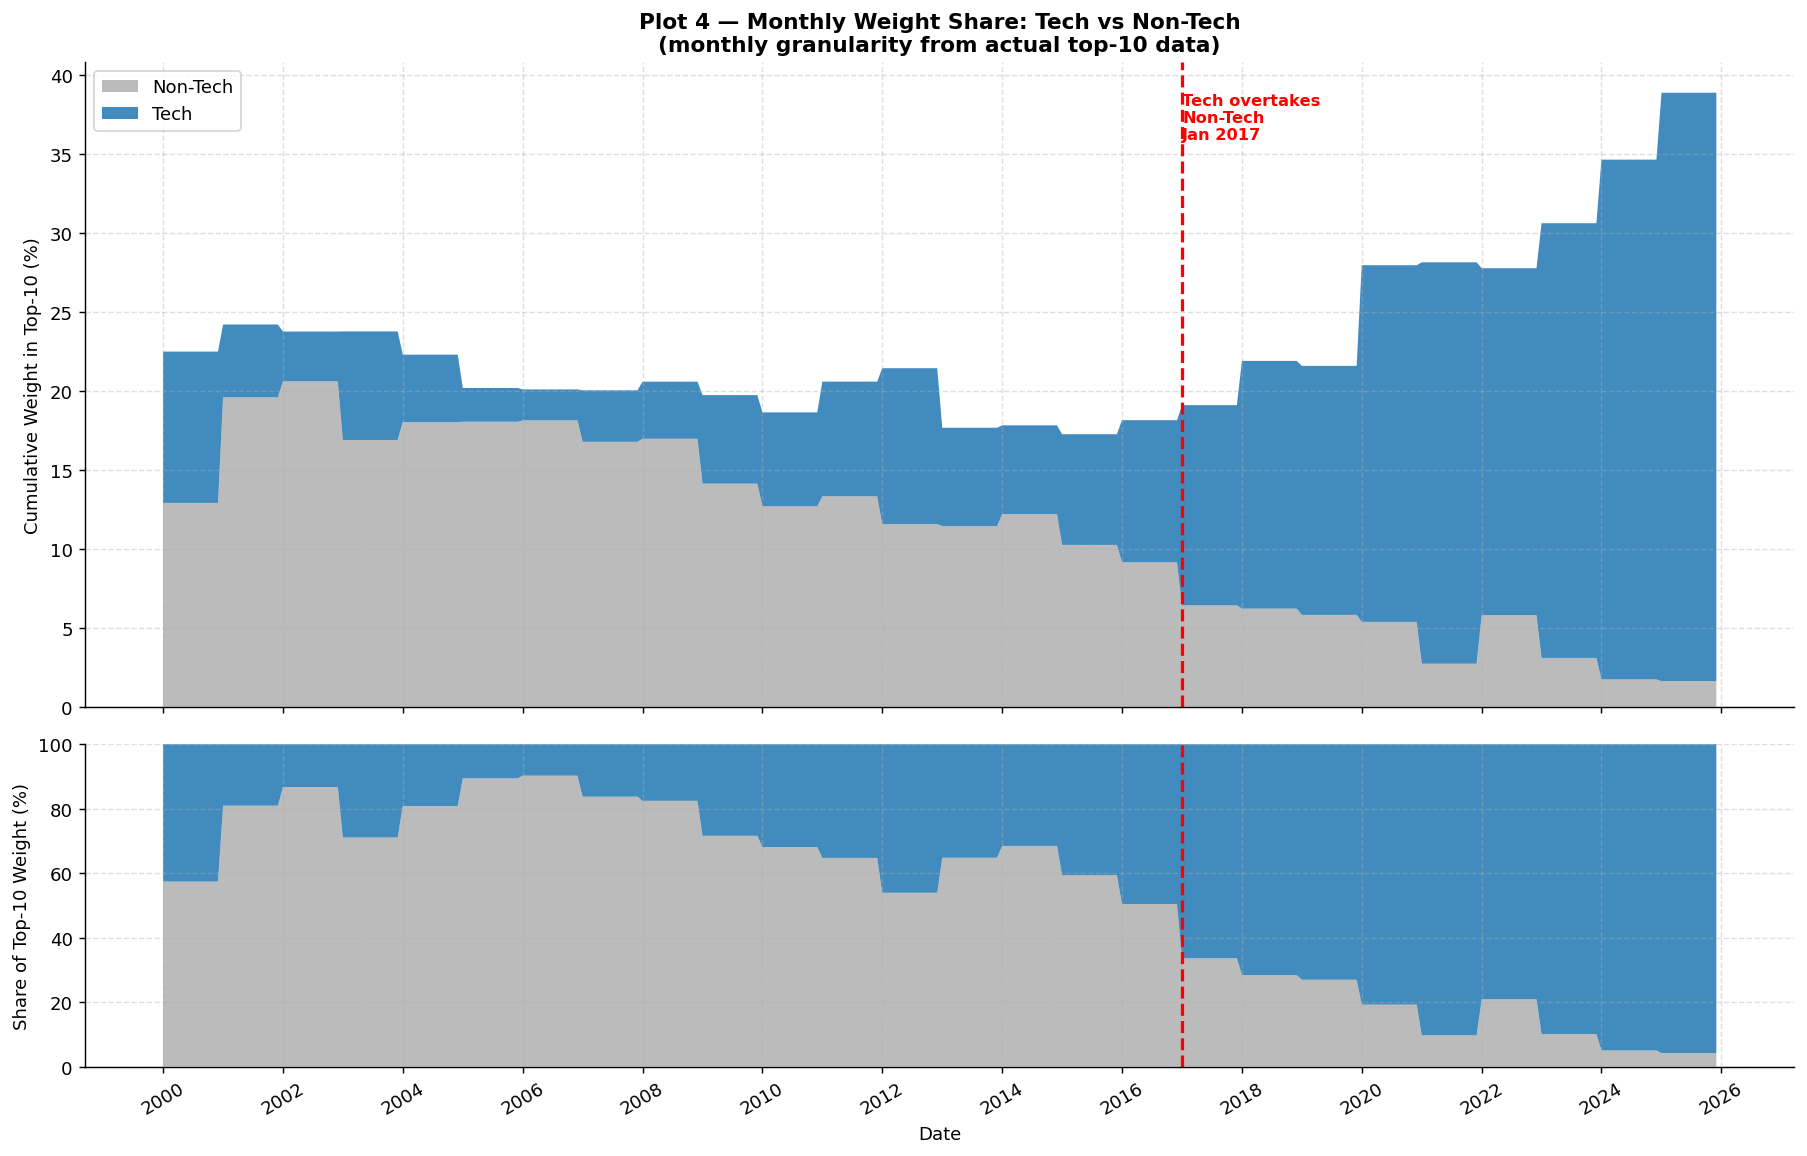

In [4]:
# PLOT 4 — Monthly Weight Share: Tech vs Non-Tech (fine-grained area chart)
# Use actual monthly data: sum weights by sector × month
df4 = (monthly_df.groupby(['Date','Sector'])['Weight'].sum().unstack(fill_value=0).reset_index())

if 'Tech' not in df4.columns:    
    df4['Tech'] = 0
if 'Non-Tech' not in df4.columns: 
    df4['Non-Tech'] = 0

df4['Total'] = df4['Tech'] + df4['Non-Tech']
df4['Tech_pct']  = 100 * df4['Tech'] / df4['Total']
df4['NonTech_pct'] = 100 * df4['Non-Tech'] / df4['Total']

# Crossover point
cross = df4[df4['Tech'] > df4['Non-Tech']]['Date'].min()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

ax1.stackplot(df4['Date'], df4['Non-Tech'], df4['Tech'],
              labels=['Non-Tech', 'Tech'],
              colors=[NONTECH_COLOR, TECH_COLOR], alpha=0.85)
ax1.set_ylabel('Cumulative Weight in Top-10 (%)')
ax1.set_title('Plot 4 — Monthly Weight Share: Tech vs Non-Tech\n'
              '(monthly granularity from actual top-10 data)',
              fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.4)

ax2.stackplot(df4['Date'], df4['NonTech_pct'], df4['Tech_pct'],
              labels=['Non-Tech %', 'Tech %'],
              colors=[NONTECH_COLOR, TECH_COLOR], alpha=0.85)
ax2.set_ylabel('Share of Top-10 Weight (%)')
ax2.set_ylim(0, 100)
ax2.grid(True, linestyle='--', alpha=0.4)

if pd.notna(cross):
    for ax in [ax1, ax2]:
        ax.axvline(cross, color='red', linestyle='--', lw=1.8)
    ax1.text(cross, ax1.get_ylim()[1] * 0.88, f'Tech overtakes\nNon-Tech\n{cross.strftime("%b %Y")}', color='red', fontsize=9, fontweight='bold', ha='left')
    # ax1.text(cross_year + 0.3, ax1.get_ylim()[1]*0.9, f'Tech overtakes\nNon-Tech in {int(cross_year)}', color='red', fontsize=10, fontweight='bold')

ax2.set_xlabel('Date')
# ax2.xaxis.set_major_locator(mticker.YearLocator(2))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.tick_params(axis='x', rotation=30)
plt.tight_layout()
# plt.savefig('plot4_monthly_weight_share.png', dpi=150, bbox_inches='tight')
plt.show()


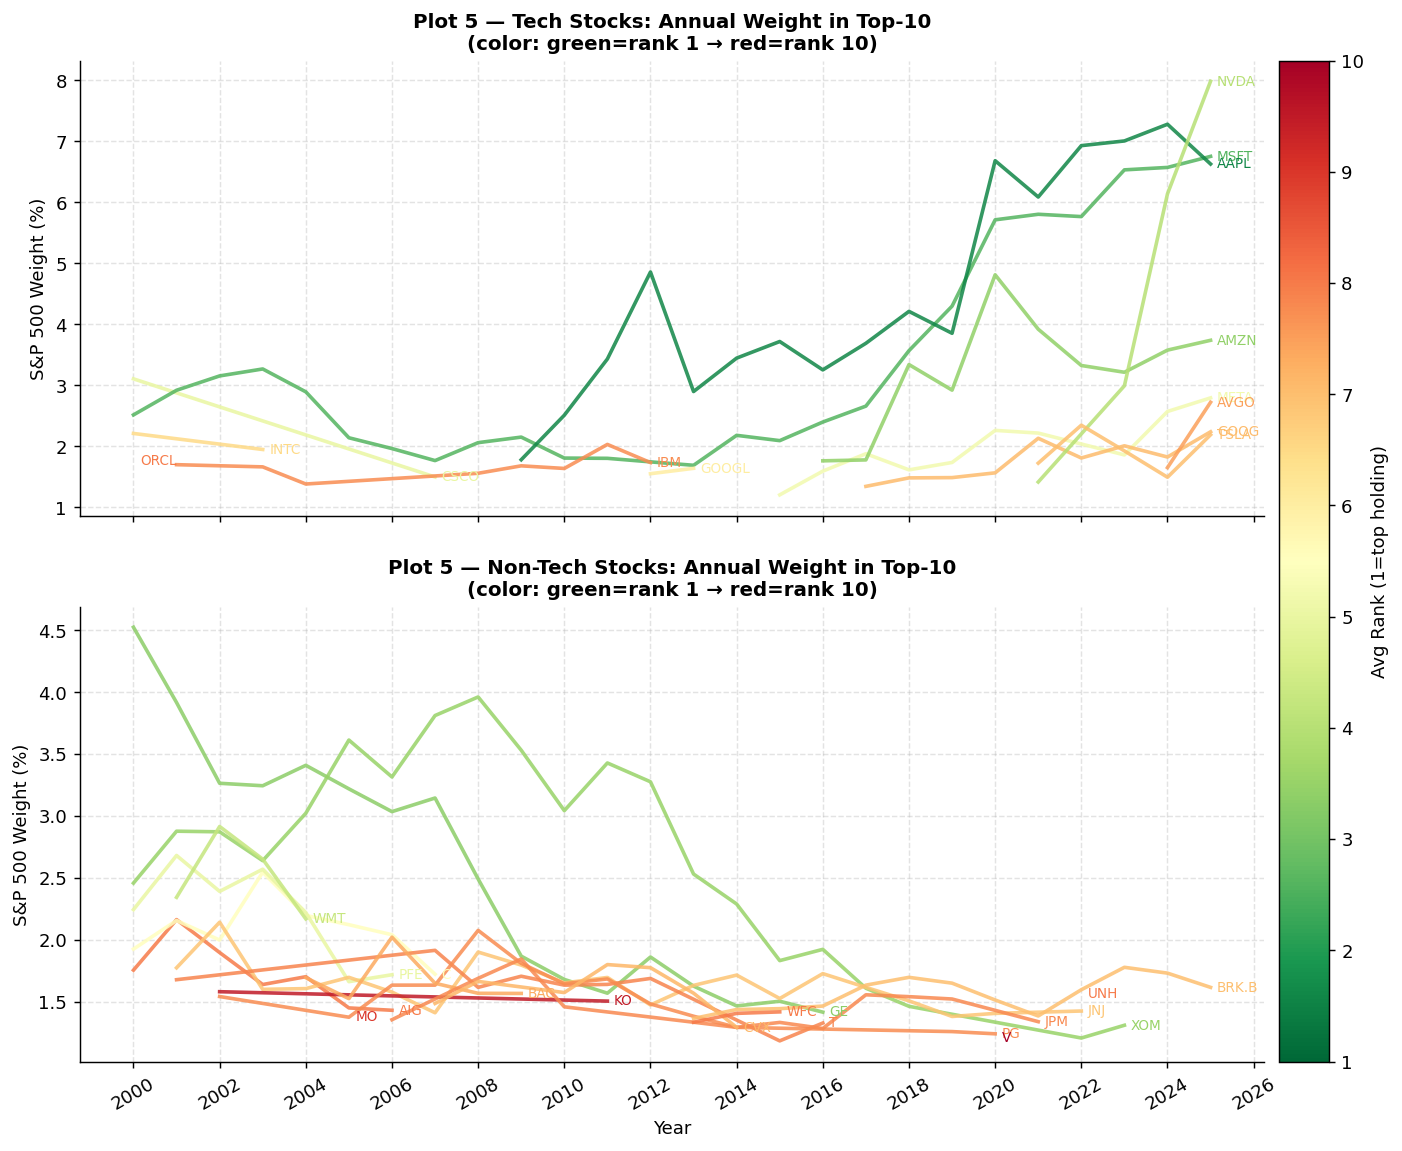

In [6]:
# PLOT 5 — Individual Stock Weight Trajectory (colored by Rank)
# One line per ticker, showing annual weight across years in the top 10.
# Color = average rank (darker = higher rank / bigger holding)

df5 = monthly_df.groupby(['Year','Ticker','Sector'])[['Weight','Rank']].mean().reset_index()

rank_cmap = plt.cm.RdYlGn_r  # rank 1 = darkest red (most important)

fig, (ax_tech, ax_nontech) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for ax, sector, title_label in [
    (ax_tech,    'Tech',     'Tech Stocks'),
    (ax_nontech, 'Non-Tech', 'Non-Tech Stocks')
]:
    tickers_in = df5[df5['Sector'] == sector]['Ticker'].unique()
    for ticker in tickers_in:
        sub = df5[(df5['Ticker'] == ticker) & (df5['Sector'] == sector)].sort_values('Year')
        avg_rank = sub['Rank'].mean()
        color = rank_cmap((avg_rank - 1) / 9)   # rank 1→0, rank 10→1

        ax.plot(sub['Year'], sub['Weight'], lw=2, color=color, alpha=0.85)
        # Label at last point
        last = sub.iloc[-1]
        ax.text(last['Year'] + 0.15, last['Weight'], ticker,
                fontsize=7.5, va='center', color=color)

    ax.set_ylabel('S&P 500 Weight (%)')
    ax.set_title(f'Plot 5 — {title_label}: Annual Weight in Top-10\n'
                 f'(color: green=rank 1 → red=rank 10)',
                 fontsize=11, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.35)

sm = plt.cm.ScalarMappable(cmap=rank_cmap, norm=plt.Normalize(1, 10))
sm.set_array([])
fig.colorbar(sm, ax=[ax_tech, ax_nontech], label='Avg Rank (1=top holding)', pad=0.01)

ax_nontech.set_xlabel('Year')
ax_nontech.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax_nontech.tick_params(axis='x', rotation=30)
# plt.tight_layout()
# plt.savefig('plot5_weight_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()


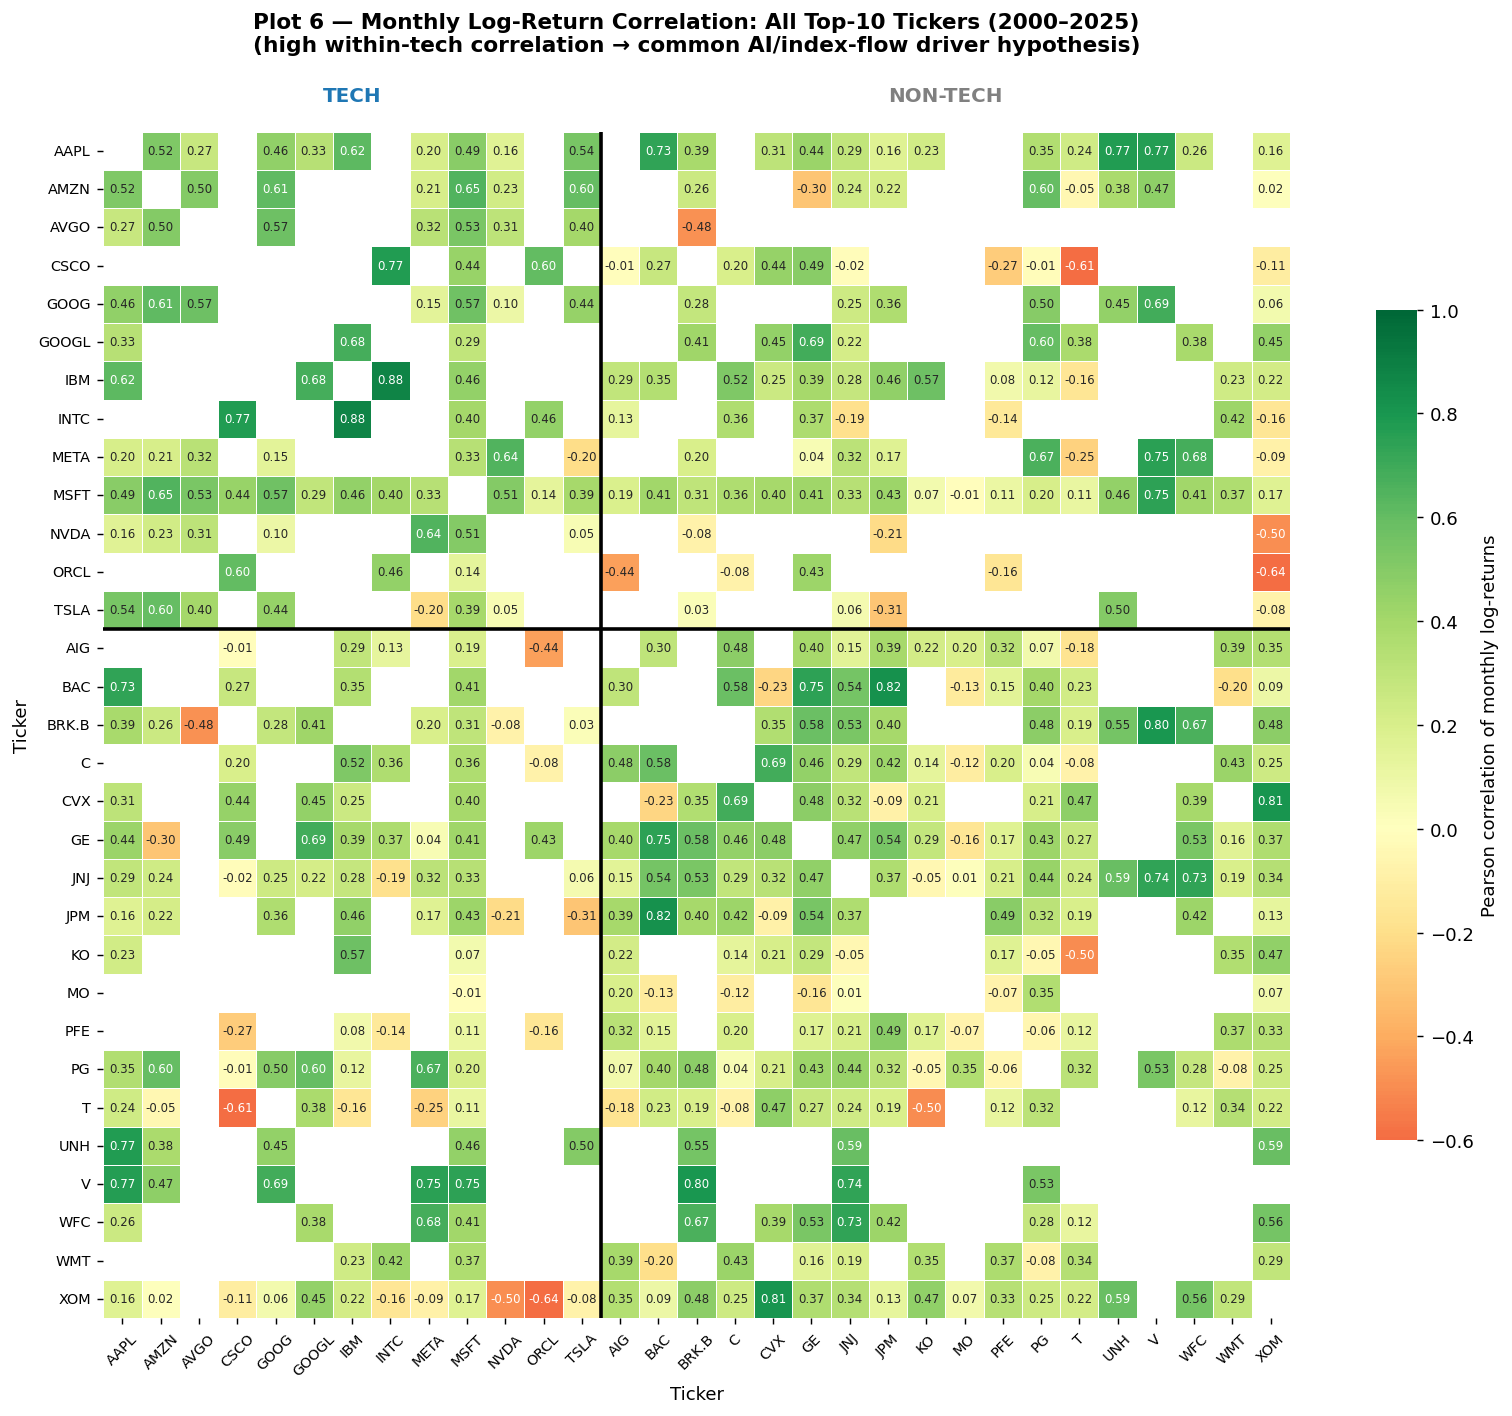

In [9]:
# PLOT 6 — Correlation Heatmap of Monthly Log-Returns
# For each ticker, compute monthly log-return from Close.
# Pivot to wide format, then correlate.
# High within-tech correlation → common factor driving prices (AI / index flows).

df6 = monthly_df[['Date','Ticker','Close','Sector']].copy()
df6 = df6.sort_values(['Ticker','Date'])
df6['LogReturn'] = df6.groupby('Ticker')['Close'].transform(
    lambda x: np.log(x / x.shift(1))
)
df6 = df6.dropna(subset=['LogReturn'])

pivot6 = df6.pivot_table(index='Date', columns='Ticker', values='LogReturn')
corr6  = pivot6.corr()

# Order: tech first, then non-tech; within each group sort alphabetically
tech_tickers_present    = sorted([t for t in corr6.columns if t in TECH])
nontech_tickers_present = sorted([t for t in corr6.columns if t not in TECH])
order = tech_tickers_present + nontech_tickers_present
corr6 = corr6.loc[order, order]

# Build color bar for sector annotation
sector_colors = [TECH_COLOR if t in TECH else NONTECH_COLOR for t in order]

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.eye(len(corr6), dtype=bool)   # mask diagonal

sns.heatmap(corr6, ax=ax, mask=mask,
            cmap='RdYlGn', center=0, vmin=-0.6, vmax=1.0,
            annot=True, fmt='.2f', annot_kws={'size': 6.5},
            linewidths=0.4, square=True,
            cbar_kws={'label': 'Pearson correlation of monthly log-returns',
                      'shrink': 0.7})

# Divider line between tech / non-tech
n_tech = len(tech_tickers_present)
ax.axhline(n_tech, color='black', lw=2)
ax.axvline(n_tech, color='black', lw=2)
ax.text(n_tech/2, -0.8, 'TECH', ha='center', fontsize=11,
        fontweight='bold', color=TECH_COLOR)
ax.text(n_tech + len(nontech_tickers_present)/2, -0.8, 'NON-TECH',
        ha='center', fontsize=11, fontweight='bold', color='gray')

ax.set_title('Plot 6 — Monthly Log-Return Correlation: All Top-10 Tickers (2000–2025)\n'
             '(high within-tech correlation → common AI/index-flow driver hypothesis)\n\n\n',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
# plt.savefig('plot6_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()